In [9]:
import tensorflow as tf
import numpy as np

# 1. Load MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# 2. Updated Prepare Data (Strictly 28x28x1 for Custom CNN)
def prepare_data_original(images):
    # Normalize pixel values to the interval [0, 1] [cite: 157, 163]
    images = images / 255.0
    # Add one more dimension to represent the single channel (Grayscale) 
    # This makes the shape (Batch, 28, 28, 1) [cite: 158, 163]
    images = np.expand_dims(images, axis=-1)
    return images

train_images = prepare_data_original(train_images)
test_images = prepare_data_original(test_images)

# 3. Convert labels to one-hot encoding [cite: 158, 163]
num_classes = 10
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes)

print("Final train images shape:", train_images.shape) # Should be (60000, 28, 28, 1)

Final train images shape: (60000, 28, 28, 1)


In [10]:
import tensorflow as tf

def build_custom_cnn(input_shape=(28, 28, 1), num_classes=10):
    model_input = tf.keras.layers.Input(shape=input_shape)
    
    # --- Feature Extraction Block ---
    # First Conv Layer: 32 filters, 3x3 kernel
    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv_1')(model_input)
    x = tf.keras.layers.MaxPooling2D((2, 2), name='pool_1')(x)
    
    # Second Conv Layer: 64 filters, 3x3 kernel
    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', name='conv_2')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2), name='pool_2')(x)
    
    # --- Classification Block ---
    x = tf.keras.layers.Flatten(name='flatten')(x)
    # Dense hidden layer with 128 neurons
    x = tf.keras.layers.Dense(128, activation='relu', name='dense_1')(x)
    # Final output layer with Softmax for 10 classes
    model_output = tf.keras.layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    
    return tf.keras.Model(inputs=model_input, outputs=model_output)

# Note: Custom CNN usually takes (28, 28, 1) rather than (32, 32, 3)
model = build_custom_cnn(input_shape=(28, 28, 1))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9494 - loss: 0.1649 - val_accuracy: 0.9858 - val_loss: 0.0494
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9846 - loss: 0.0505 - val_accuracy: 0.9863 - val_loss: 0.0446
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9894 - loss: 0.0349 - val_accuracy: 0.9887 - val_loss: 0.0409
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9920 - loss: 0.0254 - val_accuracy: 0.9895 - val_loss: 0.0313
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9942 - loss: 0.0189 - val_accuracy: 0.9905 - val_loss: 0.0374
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9951 - loss: 0.0143 - val_accuracy: 0.9932 - val_loss: 0.0331
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9957 - loss: 0.0118 - val_accuracy: 0.9933 - val_loss: 0.0328
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9966 - loss: 0.0093 - v

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Batch Test Accuracy: 99.11%


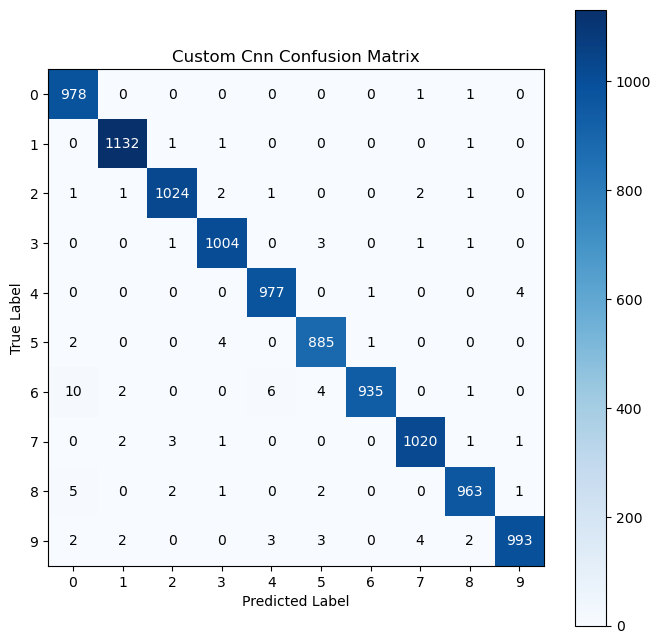

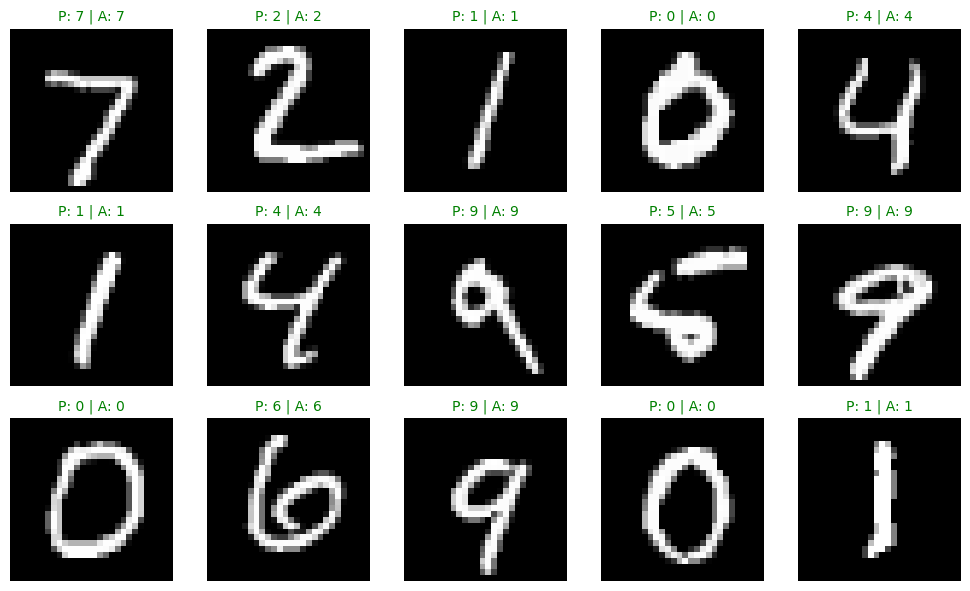

In [12]:
import matplotlib.pyplot as plt
# 1. Get predictions for the entire test set
batch_predictions = model.predict(test_images)
y_pred = np.argmax(batch_predictions, axis=1)
y_true = np.argmax(test_labels, axis=1)

# 2. Calculate accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Batch Test Accuracy: {accuracy * 100:.2f}%")
# 3. Create Confusion Matrix manually
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

# 4. Plot using Matplotlib
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Add labels to the axes
ax.set(xticks=np.arange(num_classes),
       yticks=np.arange(num_classes),
       xticklabels=range(num_classes), 
       yticklabels=range(num_classes),
       title='Custom Cnn Confusion Matrix',
       ylabel='True Label',
       xlabel='Predicted Label')

# Annotate each cell with the numeric value
thresh = cm.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.show()
# 5. Visualize first 15 results
plt.figure(figsize=(10, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(test_images[i][:,:,0], cmap='gray')
    
    color = 'green' if y_pred[i] == y_true[i] else 'red'
    plt.title(f"P: {y_pred[i]} | A: {y_true[i]}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Assuming your model variable is named 'model'
model.save('customcnn_model.h5')

print("Model saved successfully as customcnn_model.h5")

Model saved successfully as customcnn_model.h5


In [25]:
import tensorflow as tf
import numpy as np

# 1. Load your trained model
model = tf.keras.models.load_model('customcnn_model.h5')

# 2. Prepare a representative dataset
# This is required to calibrate the dynamic range of activations
def representative_data_gen():
  # Use a small subset of your training images (e.g., 100 samples)
  for input_value in tf.data.Dataset.from_tensor_slices(train_images).batch(1).take(100):
    yield [tf.cast(input_value, tf.float32)]

# 3. Set up the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# 4. Enforce Full Integer Quantization
# This ensures that both inputs and outputs are INT8
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 5. Convert and save the model
tflite_model_quant = converter.convert()

with open('customcnn_model.tflite', 'wb') as f:
    f.write(tflite_model_quant)

print("Quantization complete: customcnn_model.tflite")

INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmp1rfoel6s\assets


INFO:tensorflow:Assets written to: C:\Users\ng822\AppData\Local\Temp\tmp1rfoel6s\assets


Saved artifact at 'C:\Users\ng822\AppData\Local\Temp\tmp1rfoel6s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1861184213776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861184417488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861205343312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861205336400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861204102608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861204102032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861204102224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1861204101648: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantization complete: customcnn_model.tflite


In [26]:
import os

def convert_tflite2cc(tflite_path, cc_path, model_name="customcnn_model"):
    """Converts a TFLite file to a C++ file containing a byte array."""
    with open(tflite_path, 'rb') as f:
        tflite_content = f.read()
    
    hex_line = [f'0x{byte:02x}' for byte in tflite_content]
    
    with open(cc_path, 'w') as f:
        f.write(f'#include "{model_name}.h"\n\n')
        f.write(f'const unsigned char g_{model_name}_data[] = {{\n')
        # Write 12 hex values per line for readability
        for i in range(0, len(hex_line), 12):
            f.write('  ' + ', '.join(hex_line[i:i+12]) + ',\n')
        f.write(f'}};\n\n')
        f.write(f'const int g_{model_name}_data_len = {len(tflite_content)};\n')

# Generate the .cc file
convert_tflite2cc('customcnn_model.tflite', "customcnn_model.cc")

In [27]:
def generate_h_file(h_path, model_name="customcnn_model"):
    with open(h_path, 'w') as f:
        f.write(f'#ifndef {model_name.upper()}_DATA_H_\n')
        f.write(f'#define {model_name.upper()}_DATA_H_\n\n')
        f.write(f'extern const unsigned char g_{model_name}_data[];\n')
        f.write(f'extern const int g_{model_name}_data_len;\n\n')
        f.write(f'#endif // {model_name.upper()}_DATA_H_\n')

# Generate the .h file
generate_h_file("customcnn_model.h")

In [28]:
interpreter = tf.lite.Interpreter(model_path="customcnn_model.tflite")
interpreter.allocate_tensors()

print("=== Tensors ===")
for t in interpreter.get_tensor_details():
    print(
        f"name={t['name']}, "
        f"shape={t['shape']}, "
        f"dtype={t['dtype']}"
    )

print("\n=== Ops ===")
for op in interpreter._get_ops_details():
    print(op["op_name"])


=== Tensors ===
name=serving_default_input_layer:0, shape=[ 1 28 28  1], dtype=<class 'numpy.int8'>
name=arith.constant, shape=[1], dtype=<class 'numpy.int32'>
name=arith.constant1, shape=[1], dtype=<class 'numpy.int32'>
name=arith.constant2, shape=[], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst, shape=[10], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst1, shape=[ 10 128], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst2, shape=[128], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst3, shape=[ 128 1600], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst4, shape=[64], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst5, shape=[64  3  3 32], dtype=<class 'numpy.int8'>
name=tfl.pseudo_qconst6, shape=[32], dtype=<class 'numpy.int32'>
name=tfl.pseudo_qconst7, shape=[32  3  3  1], dtype=<class 'numpy.int8'>
name=functional_1/conv_1_1/Relu;functional_1/conv_1_1/BiasAdd;functional_1/conv_1_1/convolution;functional_1/conv_1_1/Squeeze1, shape=[ 1 26 26 32], dtype=<class 'numpy.int8

c:\Users\ng822\anaconda3\envs\421\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
